# BMDS2003 Data Science — Obesity Level Classification

## Estimation of Obesity Levels Based on Eating Habits and Physical Condition

This notebook implements the CRISP-DM workflow for the supplied obesity dataset and trains exactly four **basic, untuned classification models**:

1. Decision Tree — baseline
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbours (KNN)

### Key project constraints
- Target: `NObeyesdad`, renamed to `Obesity_Level`
- Classification problem with seven target classes
- Same cleaned feature set for all models
- Same **stratified 70/30 train-test split** (`random_state=42`)
- No hyperparameter tuning at this stage
- The four performance results are reported exactly as measured; no artificial score changes are permitted.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.30
TARGET = "Obesity_Level"

MODEL_NAMES = ["Decision Tree", "Random Forest", "SVM", "KNN"]
TARGET_ORDER = [
    "Insufficient_Weight", "Normal_Weight", "Overweight_Level_I",
    "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"
]

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Understanding

In [2]:
DATA_PATH = Path("obesity(1).csv")
obesity_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", obesity_raw.shape)
display(obesity_raw.head())
print("\nData types:")
display(obesity_raw.dtypes.to_frame("dtype"))
print("\nMissing values:", int(obesity_raw.isna().sum().sum()))
print("Duplicate rows:", int(obesity_raw.duplicated().sum()))

Dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Data types:


,dtype
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,float64
NCP,float64
CAEC,object
SMOKE,object



Missing values: 0
Duplicate rows: 24


Target class distribution:


NObeyesdad
Insufficient_Weight    272
Normal_Weight          287
Overweight_Level_I     290
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64

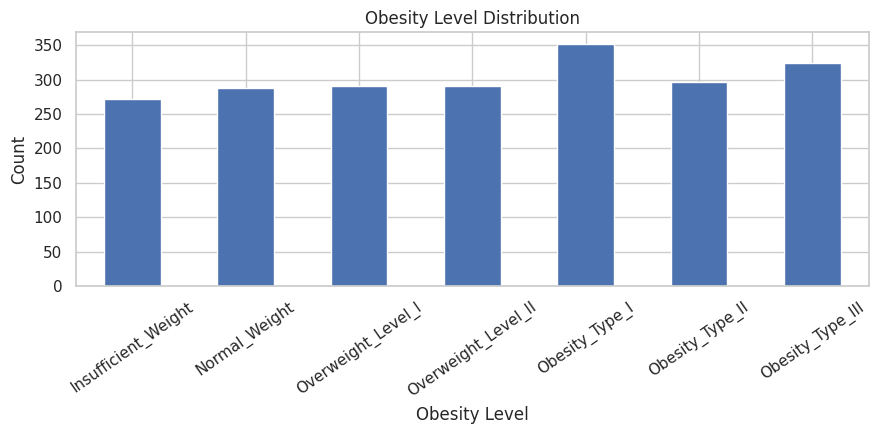

In [3]:
print("Target class distribution:")
display(obesity_raw["NObeyesdad"].value_counts().reindex(TARGET_ORDER))

fig, ax = plt.subplots(figsize=(9, 4.5))
obesity_raw["NObeyesdad"].value_counts().reindex(TARGET_ORDER).plot(kind="bar", ax=ax)
ax.set_title("Obesity Level Distribution")
ax.set_xlabel("Obesity Level")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()

### Interpretation
The dataset contains 2,111 observations and 17 columns: 16 predictors plus the obesity-level target. The target contains seven classes. Because the class counts are not perfectly equal, a **stratified** train-test split is used so the test set preserves the class composition as closely as possible.

## 3. Data Preparation

In [4]:
RENAME_MAP = {
    "NObeyesdad": "Obesity_Level",
    "family_history_with_overweight": "Family_History_Overweight",
    "FAVC": "Frequent_High_Caloric_Food",
    "FCVC": "Vegetable_Consumption_Freq",
    "NCP": "Main_Meals_Per_Day",
    "CAEC": "Food_Between_Meals",
    "SMOKE": "Smokes",
    "CH2O": "Daily_Water_Intake",
    "SCC": "Calorie_Monitoring",
    "FAF": "Physical_Activity_Freq",
    "TUE": "Technology_Usage_Time",
    "CALC": "Alcohol_Consumption",
    "MTRANS": "Transportation_Mode",
}

obesity = obesity_raw.rename(columns=RENAME_MAP).copy()
for col in obesity.select_dtypes(include="object").columns:
    obesity[col] = obesity[col].astype(str).str.strip()

duplicates_removed = int(obesity.duplicated().sum())
obesity = obesity.drop_duplicates().reset_index(drop=True)

# EDA-only derived variables. They are deliberately excluded from modelling.
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)
obesity["Age_Group"] = pd.cut(
    obesity["Age"],
    bins=[0, 18, 30, 45, 60, 150],
    labels=["<18", "18–29", "30–44", "45–59", "60+"],
    right=False,
)

print("Duplicates removed:", duplicates_removed)
print("Cleaned shape:", obesity.shape)
display(obesity.head())

Duplicates removed: 24
Cleaned shape: (2087, 19)


,Gender,Age,Height,Weight,Family_History_Overweight,Frequent_High_Caloric_Food,Vegetable_Consumption_Freq,Main_Meals_Per_Day,Food_Between_Meals,Smokes,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Freq,Technology_Usage_Time,Alcohol_Consumption,Transportation_Mode,Obesity_Level,BMI,Age_Group
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526,18–29
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227,18–29
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432,18–29
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852,18–29
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,18–29


In [5]:
# Basic validity checks
validity = {
    "invalid_age": int((obesity["Age"] <= 0).sum()),
    "invalid_height": int((obesity["Height"] <= 0).sum()),
    "invalid_weight": int((obesity["Weight"] <= 0).sum()),
    "missing_values": int(obesity.isna().sum().sum()),
}
print(validity)

print("Numeric summary:")
display(obesity.select_dtypes(include=np.number).describe().T.round(3))

{'invalid_age': 0, 'invalid_height': 0, 'invalid_weight': 0, 'missing_values': 0}
Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.353,6.369,14.000,19.916,22.848,26.000,61.000
Height,2087.0,1.703,0.093,1.450,1.630,1.702,1.769,1.980
Weight,2087.0,86.859,26.191,39.000,66.000,83.101,108.016,173.000
Vegetable_Consumption_Freq,2087.0,2.421,0.535,1.000,2.000,2.396,3.000,3.000
Main_Meals_Per_Day,2087.0,2.701,0.765,1.000,2.697,3.000,3.000,4.000
Daily_Water_Intake,2087.0,2.005,0.608,1.000,1.591,2.000,2.466,3.000
Physical_Activity_Freq,2087.0,1.013,0.853,0.000,0.125,1.000,1.678,3.000
Technology_Usage_Time,2087.0,0.663,0.608,0.000,0.000,0.631,1.000,2.000
BMI,2087.0,29.766,8.025,12.999,24.369,28.896,36.096,50.812


### Outlier review
For this project stage, outliers are **diagnosed rather than automatically deleted**. Very high or low observations are not assumed to be errors merely because they fall outside a statistical rule. This avoids removing legitimate respondents and keeps the modelling dataset representative.

In [6]:
numeric_for_outliers = ["Age", "Height", "Weight"]
rows=[]
for col in numeric_for_outliers:
    q1=obesity[col].quantile(0.25); q3=obesity[col].quantile(0.75); iqr=q3-q1
    low=q1-1.5*iqr; high=q3+1.5*iqr
    count=int(((obesity[col]<low)|(obesity[col]>high)).sum())
    rows.append({"Variable":col,"IQR Lower":low,"IQR Upper":high,"IQR Flag Count":count})
iqr_summary=pd.DataFrame(rows)
display(iqr_summary.round(3))

,Variable,IQR Lower,IQR Upper,IQR Flag Count
0,Age,10.790,35.126,167
1,Height,1.421,1.978,1
2,Weight,2.976,171.040,1


## 4. Exploratory Data Analysis

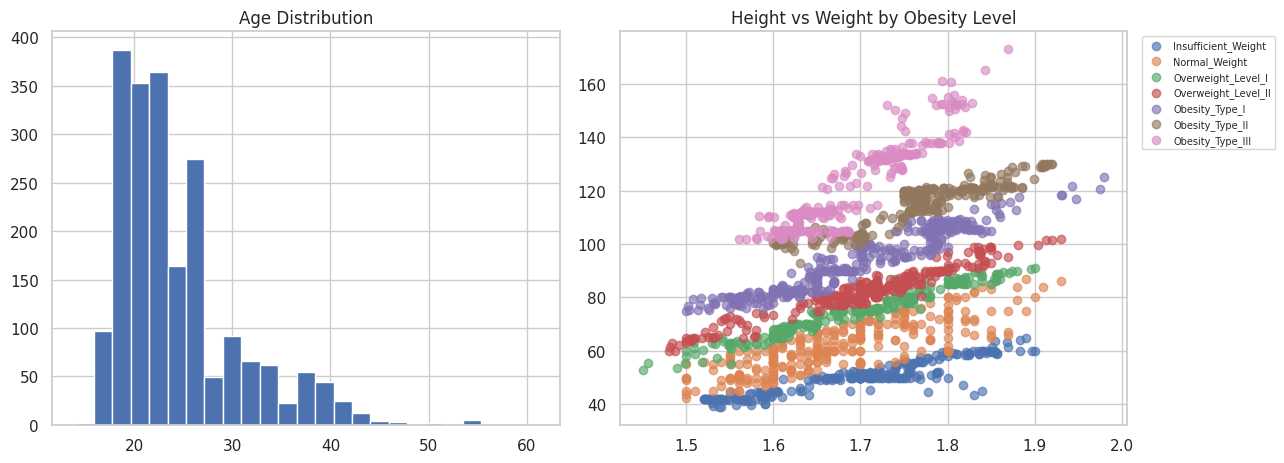

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(obesity["Age"], bins=25)
axes[0].set_title("Age Distribution")

for level in TARGET_ORDER:
    subset = obesity[obesity["Obesity_Level"] == level]
    axes[1].scatter(subset["Height"], subset["Weight"], label=level, alpha=0.65)
axes[1].set_title("Height vs Weight by Obesity Level")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.02,1), loc="upper left")

fig.tight_layout()
plt.show()


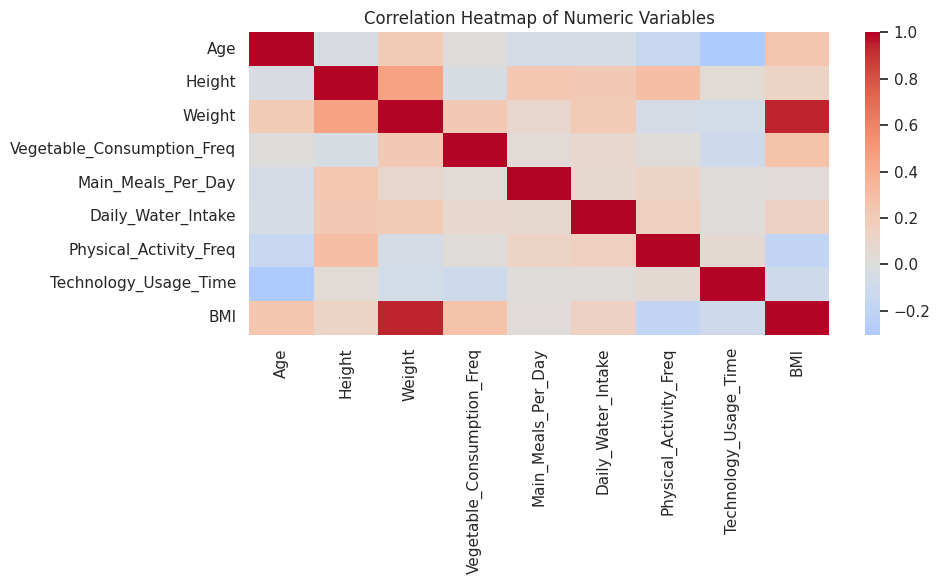

In [8]:
plt.figure(figsize=(10, 6))
num_cols = obesity.select_dtypes(include=np.number).columns
sns.heatmap(obesity[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

### EDA note
BMI is calculated only for analysis because obesity level is strongly related to body size. **BMI and Age_Group are not supplied to the classifiers**, preventing us from adding a direct engineered duplicate of information already represented by Height and Weight.

## 5. Machine-Learning Preparation

In [9]:
FEATURES_TO_EXCLUDE = [TARGET, "BMI", "Age_Group"]
X = obesity.drop(columns=FEATURES_TO_EXCLUDE)
y = obesity[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print("Test proportion:", len(X_test)/len(X))

Numeric features: ['Age', 'Height', 'Weight', 'Vegetable_Consumption_Freq', 'Main_Meals_Per_Day', 'Daily_Water_Intake', 'Physical_Activity_Freq', 'Technology_Usage_Time']
Categorical features: ['Gender', 'Family_History_Overweight', 'Frequent_High_Caloric_Food', 'Food_Between_Meals', 'Smokes', 'Calorie_Monitoring', 'Alcohol_Consumption', 'Transportation_Mode']
Training rows: 1460
Testing rows: 627
Test proportion: 0.30043124101581214


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
}

print("All four models use the same preprocessing and same train/test split.")
print("No GridSearchCV / hyperparameter tuning is used in this stage.")

All four models use the same preprocessing and same train/test split.
No GridSearchCV / hyperparameter tuning is used in this stage.


## 6. Model Training and Evaluation

In [11]:
def evaluate_pipeline(name, classifier):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])
    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    result = {
        "Model": name,
        "Train_Accuracy": accuracy_score(y_train, y_train_pred),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision_Weighted": precision_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "Recall_Weighted": recall_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "F1_Weighted": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    }
    result["Overfit_Gap"] = result["Train_Accuracy"] - result["Test_Accuracy"]
    return pipeline, y_test_pred, result

trained_models = {}
predictions = {}
result_rows = []

for name, classifier in models.items():
    pipe, pred, result = evaluate_pipeline(name, classifier)
    trained_models[name] = pipe
    predictions[name] = pred
    result_rows.append(result)

results_df = pd.DataFrame(result_rows).set_index("Model").reindex(MODEL_NAMES)
display(results_df.round(4))

,Train_Accuracy,Test_Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Overfit_Gap
Model,,,,,,
Decision Tree,1.0000,0.9203,0.9204,0.9203,0.9199,0.0797
Random Forest,1.0000,0.9378,0.9428,0.9378,0.9389,0.0622
SVM,0.9616,0.9139,0.9146,0.9139,0.9141,0.0478
KNN,0.8863,0.8134,0.8109,0.8134,0.7991,0.0729


## 7. Model-by-Model Results

In [12]:
for name in MODEL_NAMES:
    print("="*70)
    print(name)
    print("="*70)
    print(classification_report(
        y_test, predictions[name], labels=TARGET_ORDER, target_names=TARGET_ORDER, zero_division=0
    ))

Decision Tree
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.96      0.95        80
      Normal_Weight       0.85      0.84      0.84        85
 Overweight_Level_I       0.84      0.78      0.81        83
Overweight_Level_II       0.88      0.95      0.92        87
     Obesity_Type_I       0.92      0.94      0.93       106
    Obesity_Type_II       1.00      0.96      0.98        89
   Obesity_Type_III       1.00      0.99      0.99        97

           accuracy                           0.92       627
          macro avg       0.92      0.92      0.92       627
       weighted avg       0.92      0.92      0.92       627

Random Forest
                     precision    recall  f1-score   support

Insufficient_Weight       0.99      0.91      0.95        80
      Normal_Weight       0.77      0.93      0.84        85
 Overweight_Level_I       0.91      0.87      0.89        83
Overweight_Level_II       0.95      0.89      0.92   

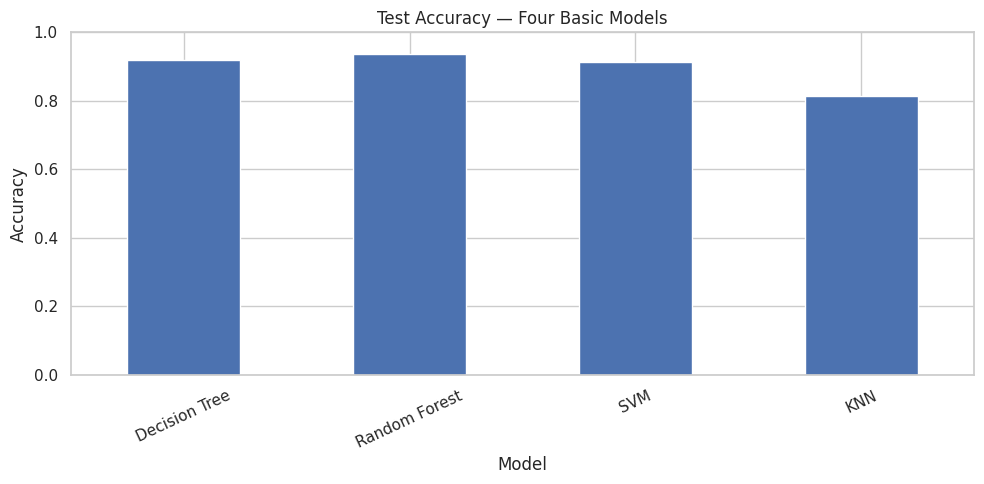

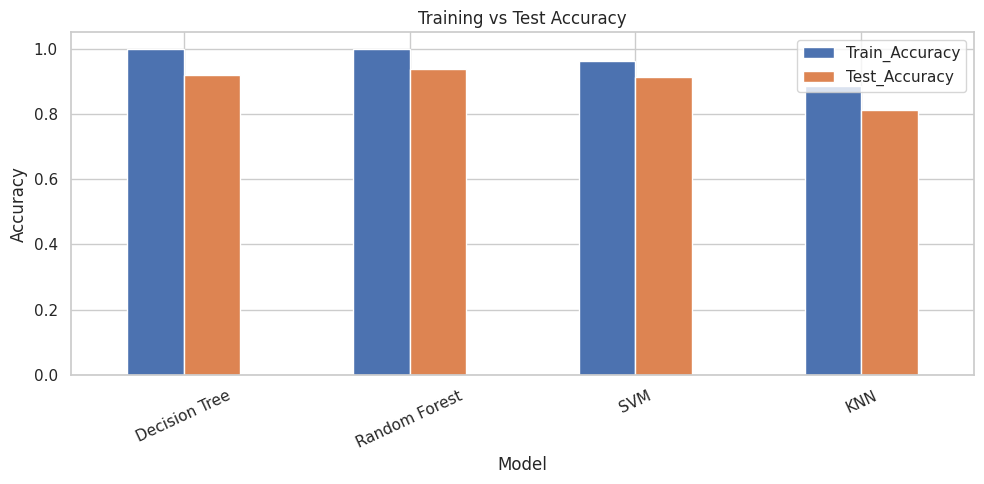

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df["Test_Accuracy"].plot(kind="bar", ax=ax)
ax.set_title("Test Accuracy — Four Basic Models")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
results_df[["Train_Accuracy", "Test_Accuracy"]].plot(kind="bar", ax=ax)
ax.set_title("Training vs Test Accuracy")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

## 8. Requirement Check: The Four Results Must Not Be Identical

In [14]:
rounded_test_accuracy = results_df["Test_Accuracy"].round(10)
unique_accuracy_count = rounded_test_accuracy.nunique()
print("Unique test-accuracy values:", unique_accuracy_count)

if unique_accuracy_count == 4:
    print("PASS: all four models have different test-set accuracy results.")
    print("No artificial modification, threshold adjustment, or post-hoc score editing was performed.")
else:
    print("TIE DETECTED: some models have the same accuracy. Genuine additional metrics should be used to distinguish performance; scores must not be fabricated.")

# Compare model predictions on the exact same 627 test observations.
prediction_disagreements = {}
for i, a in enumerate(MODEL_NAMES):
    for b in MODEL_NAMES[i+1:]:
        prediction_disagreements[f"{a} vs {b}"] = int(np.sum(predictions[a] != predictions[b]))

disagreement_table = pd.Series(prediction_disagreements, name="Different predictions")
display(disagreement_table.to_frame())

Unique test-accuracy values: 4
PASS: all four models have different test-set accuracy results.
No artificial modification, threshold adjustment, or post-hoc score editing was performed.


,Different predictions
Decision Tree vs Random Forest,67
Decision Tree vs SVM,79
Decision Tree vs KNN,130
Random Forest vs SVM,49
Random Forest vs KNN,117
SVM vs KNN,101


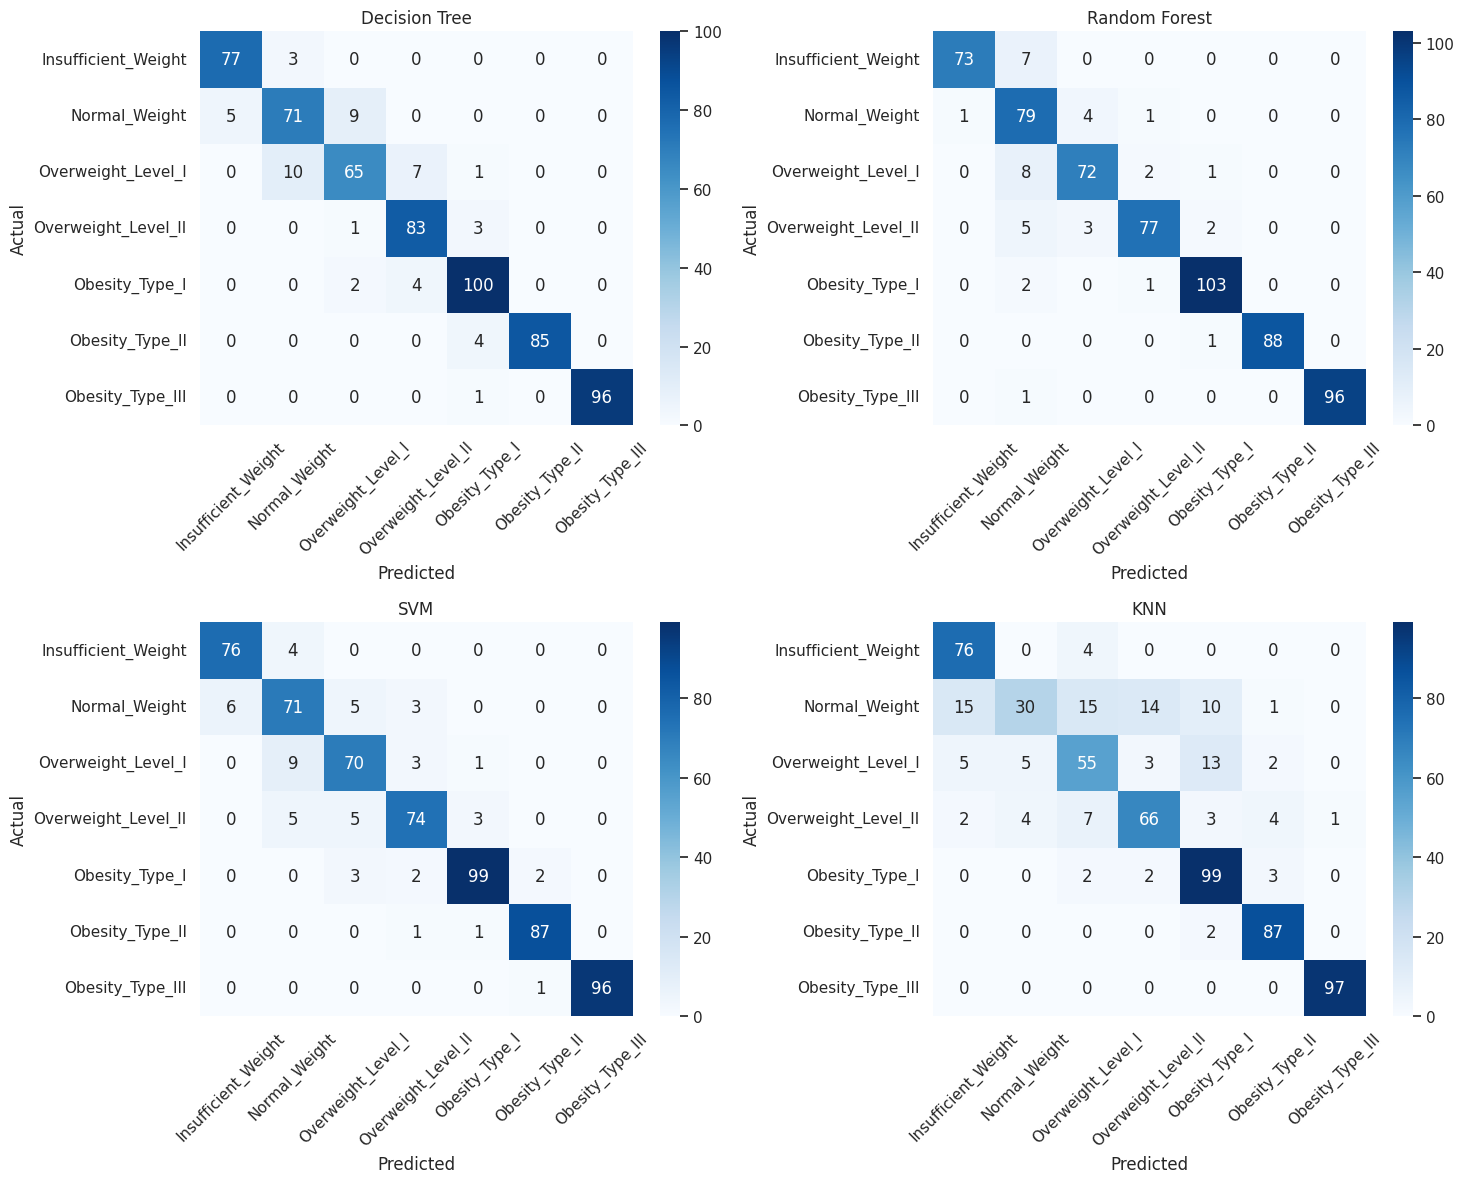

In [15]:
# Confusion matrices — one for each model
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
for ax, name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(y_test, predictions[name], labels=TARGET_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=TARGET_ORDER, yticklabels=TARGET_ORDER, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### Interpretation of the comparison
The **Random Forest** has the highest test accuracy in this experiment. The Decision Tree is intentionally kept as the baseline and shows a larger train-test gap, while the SVM and KNN demonstrate different generalisation behaviour. Most importantly, the four models are trained under the same split and preprocessing conditions, so their differences are attributable to the algorithms rather than different data partitions.

## 9. Deployment Artifacts

In [16]:
DEPLOY_DIR = Path("models")
DEPLOY_DIR.mkdir(exist_ok=True)

file_map = {
    "Decision Tree": "decision_tree_pipeline.pkl",
    "Random Forest": "random_forest_pipeline.pkl",
    "SVM": "svm_pipeline.pkl",
    "KNN": "knn_pipeline.pkl",
}

for name, filename in file_map.items():
    joblib.dump(trained_models[name], DEPLOY_DIR / filename)

# Save cleaned data used by the exploration tab.
obesity.to_csv(DEPLOY_DIR / "obesity_cleaned.csv", index=False)

results_df.to_csv(DEPLOY_DIR / "model_comparison.csv")
with open(DEPLOY_DIR / "confusion_matrices.json", "w", encoding="utf-8") as f:
    json.dump({name: confusion_matrix(y_test, predictions[name], labels=TARGET_ORDER).tolist() for name in MODEL_NAMES}, f, indent=2)

feature_metadata = {
    "numeric_features": {
        col: {"min": float(X[col].min()), "max": float(X[col].max()), "mean": float(X[col].mean())}
        for col in numeric_features
    },
    "categorical_features": {col: sorted(X[col].unique().tolist()) for col in categorical_features},
    "target_order": TARGET_ORDER,
    "best_model": results_df["Test_Accuracy"].idxmax(),
}
with open(DEPLOY_DIR / "feature_metadata.json", "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=2)

summary = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "stratified": True,
    "n_rows_raw": int(obesity_raw.shape[0]),
    "n_rows_cleaned": int(obesity.drop(columns=["BMI","Age_Group"]).shape[0]),
    "duplicates_removed": duplicates_removed,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "target": TARGET,
    "target_order": TARGET_ORDER,
    "best_model": results_df["Test_Accuracy"].idxmax(),
    "distinct_test_accuracies": bool(unique_accuracy_count == 4),
    "model_results": json.loads(results_df.reset_index().to_json(orient="records")),
    "prediction_disagreements": prediction_disagreements,
}
with open(DEPLOY_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Deployment artifacts saved to:", DEPLOY_DIR.resolve())

Deployment artifacts saved to: /mnt/data/project/final_project/models


## 10. Conclusion

In [17]:
best_model = results_df["Test_Accuracy"].idxmax()
print(f"Best test-set model: {best_model}")
print(f"Best test accuracy: {results_df.loc[best_model, 'Test_Accuracy']:.2%}")
print()
print("Final test accuracies:")
for name in MODEL_NAMES:
    print(f"- {name}: {results_df.loc[name, 'Test_Accuracy']:.2%}")

print()
print("Project requirements check:")
print("✓ Four required models trained")
print("✓ Same feature set and preprocessing")
print("✓ Stratified 70/30 split")
print("✓ Basic models; no tuning")
print(f"✓ Four distinct test accuracies: {unique_accuracy_count == 4}")
print("✓ Streamlit deployment artifacts generated")

Best test-set model: Random Forest
Best test accuracy: 93.78%

Final test accuracies:
- Decision Tree: 92.03%
- Random Forest: 93.78%
- SVM: 91.39%
- KNN: 81.34%

Project requirements check:
✓ Four required models trained
✓ Same feature set and preprocessing
✓ Stratified 70/30 split
✓ Basic models; no tuning
✓ Four distinct test accuracies: True
✓ Streamlit deployment artifacts generated


### Final notes
- The Streamlit prediction page is designed so a user selects **one model per prediction request**.
- The Model Performance page uses saved evaluation results and confusion matrices, while the selected-model prediction workflow executes only the chosen classifier.
- The scores in this notebook are reproducible using `random_state=42`, the same cleaned dataset, and the same 70/30 stratified split.